# TD Séries de Fourier avec Python et Matplotlib

## Objectifs :

### Partie 1 : SIN et COS
- Construire les fonctions SIN et COS pour différentes fréquences pour t dans [-10, 10] 
- Construire les fonctions sin(n.Omega0.t) et cos(n.Omega0.t)
- Tracer les courbes correspondantes 

### Partie 2 : EXP
- Construire les fonctions EXP complexes pour différentes fréquences pour t dans [-10, 10] 
- Construire les fonctions exp(i.n.Omega0.t) pour différentes valeurs de n et Omega0
- Tracer les courbes correspondantes 

### Partie 3 : Fonction RECT
- Faire le calcul théorique des coéfficients de Fourier 
- Visualiser la fonction qui décrit les coéfficients de Fourier
- Visualiser la reconstruction de la fonction RECT par l'équation de synthèse

### Partie 4 : Calcul des coefficients de Fourier de la fonction RECT

- Utilisation de numpy.fft -> numpy.fft.fft, numpy.fft.fftshift, numpy.fft.ifft
- Reconstruction de la fonction RECT
- Filtre passe bas
- Filtre passe haut

### Partie 5 : Cas d'une fonction bruitée

- Visualisation de la fonction
- Calcul des coefficients de Fourier
- Filtrage passe bas


In [1]:
%pip install --quiet matplotlib numpy 

# Installation pour le zoom dans les figures
%pip install --quiet ipympl


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [18]:


import numpy as np
import matplotlib.pyplot as plt


plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
print("Styles disponibles (extrait):", plt.style.available[:15])
#plt.style.use("seaborn-v0_8-colorblind")
plt.style.use("classic")

plt.rcParams["font.size"] = 11  # Changement de la taille de la font par défaut
print("Taille de police par défaut:", plt.rcParams["font.size"])

print("Matplotlib:", plt.matplotlib.__version__)

Styles disponibles (extrait): ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark']
Taille de police par défaut: 11.0
Matplotlib: 3.7.2


## Partie 1: Fonctions sin et cos

### Courbe simple (pyplot) avec labels, couleurs, titre, légendes

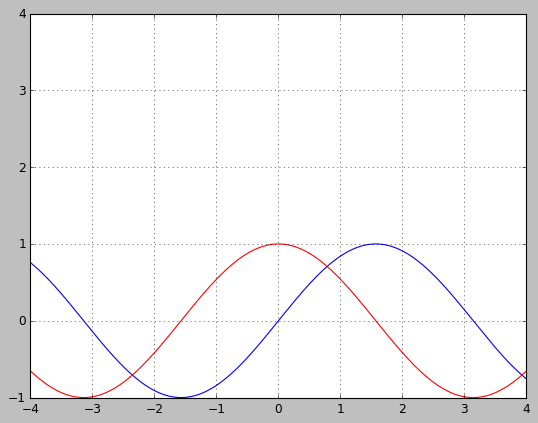

In [37]:
T0=4
w0=2*np.pi/T0
t = np.linspace(-4, 4, 1000)
plt.figure(1)
plt.clf()
plt.grid(True)
plt.plot(t, np.sin(t), -4, 4, label="sin")
plt.plot(t, np.cos(t), -4, 4, label="cos")

## Courbes Sin(n Omega0 t) et Cos(n Omega0 t) pour différentes valeurs de n

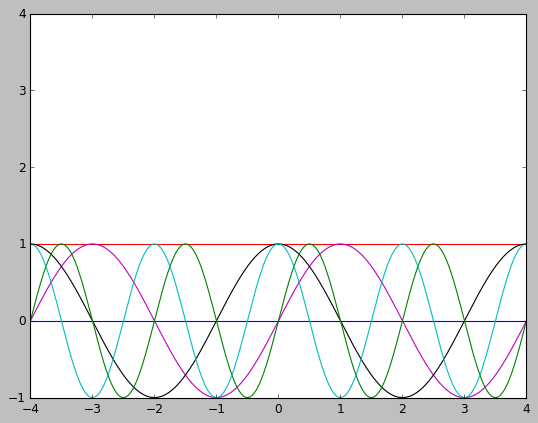

In [41]:

plt.figure(2)
plt.clf()
for n in range(0, 3):
    plt.plot(t, np.sin(n*w0*t), -4, 4, label="sin")
    plt.plot(t, np.cos(n*w0*t), -4, 4, label="cos")

## Partie 2: Fonction exponentielle

### Courbes exp(n Omega0 t) pour différentes valeurs de n
- avec partie réelle/partie imaginaire
- en 3D

<Figure size 640x480 with 0 Axes>

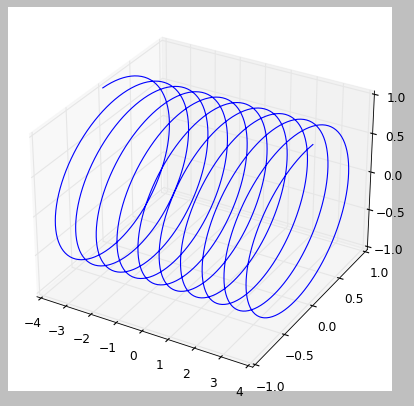

In [67]:
n=5
plt.clf()
ax = plt.figure(3).add_subplot(projection='3d')
#ax.plot(t, np.sin(n*w0*t), zs=0, zdir='z')
#ax.plot(t, np.cos(n*w0*t), zs=0, zdir='y')
ax.plot(t, np.sin(n*w0*t), np.cos(n*w0*t))

## Partie 3 : Fonction RECT
- Faire le calcul théorique des coéfficients de Fourier 
- Visualiser la fonction qui décrit les coéfficients de Fourier
- Visualiser la reconstruction de la fonction RECT par l'équation de synthèse

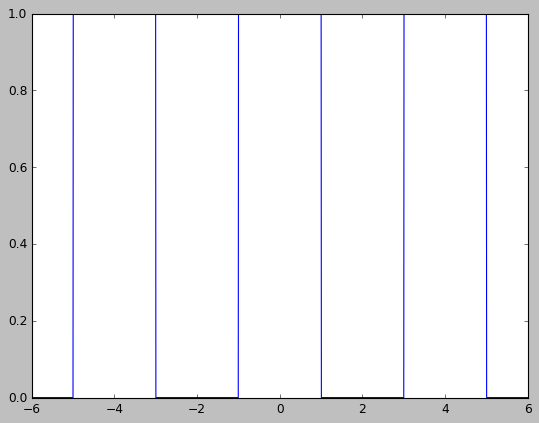

In [77]:
def r(t):
    return np.round(0.5+0.5*np.cos(2*np.pi*0.25*t))

t=np.linspace(-6, 6, 2000)
plt.plot(t,r(t))

## Partie 4.1 : Calcul des coefficients de Fourier de la fonction RECT

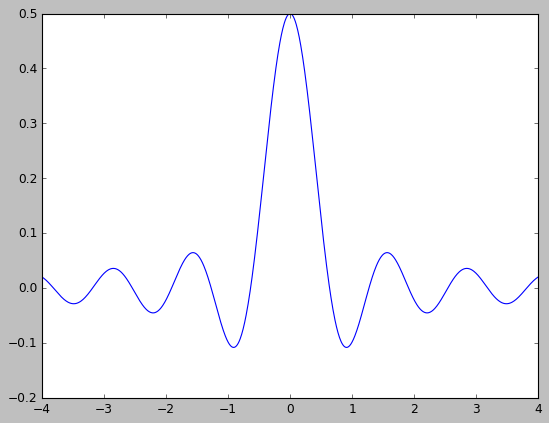

In [72]:
def coef(n):
    return 1/2*np.sinc(n*np.pi/2)

plt.plot(t, coef(t))

## Partie 4.2 : Reconstruction de la fonction rect à partir des coefficients de Fourier

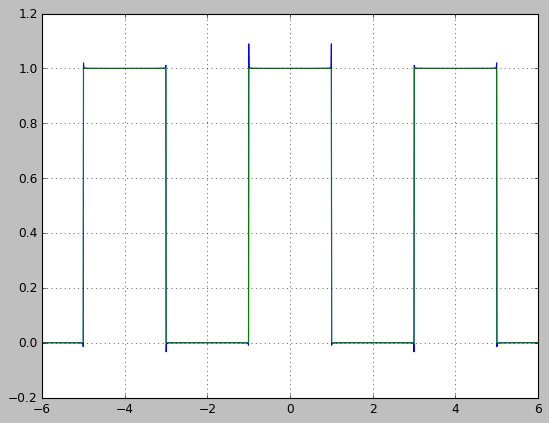

In [ ]:

def rect(t):
    N = 4000
    f=0.5*np.ones(2000)
    for n in range(1, N):
        f+=np.sin(n*np.pi/2)/(n*np.pi/2)*np.cos(n*np.pi/2*t)
    return f

plt.grid(True)
plt.plot(t, rect(t))
plt.plot(t,r(t))



## Partie 4.3 : Filtrage passe-bas 
- Suppression des coefficients de valeurs absolues les plus élevées

/opt/anaconda3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/lib/python3.9/site-packages/matplotlib/collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


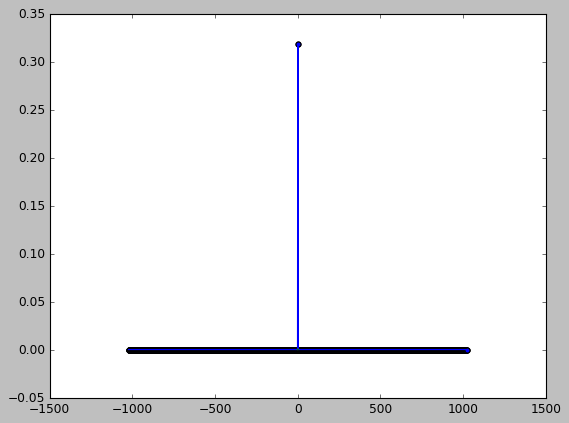

In [112]:
N=2048
a=-2
b=2
T0=4
Te=(b-a)/N
t=np.zeros(N)
absn=np.zeros(N)

for n in range(N):
    t[n]=n*Te+a
    absn[n]=-N/2+n

f=np.sin(n*np.pi/2)/(n*np.pi/2)*np.cos(n*np.pi/2*t)
Frect = np.zeros(N, dtype=complex)
Frect=np.fft.fft(f)
Frect=np.fft.fftshift(Frect)
plt.plot(absn, Frect)
plt.scatter(absn, Frect)

SeuilPB=50
FrectPB=np.zeros(N, dtype=complex)
FrectPB[int(N/2+1-SeuilPB):int(N/2+1+SeuilPB)]=Frect[int(N/2+1-SeuilPB):int(N/2+1+SeuilPB)]
iFrectPB=np.fft.fftshift(FrectPB)
rectPB=np.fft.ifft(iFrectPB)

plt.plot(t,rectPB)

## Partie 4.4 : Filtrage passe-haut 
- Suppression des coefficients de valeurs absolues les plus basses

## Partie 5 : Test sur une fonction f(t) observée sur un intervalle  [-2,2]
- Construction d'une fonction avec des variations et du bruit

rng = np.random.default_rng(42)
N=2048
a=-2
b=2
T0=4
Te=(b-a)/N
t=np.zeros(N)
absn=np.zeros(N)

for n in range(N):
    t[n]=n*Te+a
    absn[n]=-N/2+n
        
f=np.sin(t)+0.5*np.cos(5*t)+0.3*np.sin(7*t+1)+0.2*rng.normal(0, 1, N)



/opt/anaconda3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/lib/python3.9/site-packages/matplotlib/collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


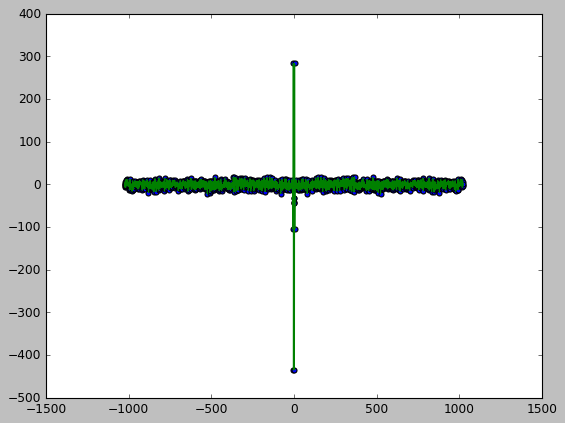

In [108]:
rng = np.random.default_rng(42)
N=2048
a=-2
b=2
T0=4
Te=(b-a)/N
t=np.zeros(N)
absn=np.zeros(N)

for n in range(N):
    t[n]=n*Te+a
    absn[n]=-N/2+n
        
f=np.sin(t)+0.5*np.cos(5*t)+0.3*np.sin(7*t+1)+0.2*rng.normal(0, 1, N)
plt.plot(t, f)
Frect = np.zeros(N, dtype=complex)
Frect=np.fft.fft(f)
Frect=np.fft.fftshift(Frect)
plt.plot(absn, Frect)
plt.scatter(absn, Frect)

### Calcul des coéfficients de Fourier et affichage

## Filtrage passe bas et affichage du résultat